## Import Libraries

In [1]:
import time
import os
import copy
import glob
import unicodedata
import string
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

import torchvision
import torchvision.transforms as transforms

import tensorflow.keras.datasets as keras_datasets

from IPython.display import display, HTML

## CNN

In [2]:
def accuracy(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))

def train_test_split(X, y, test_size=0.2, random_state=None):
    if random_state: np.random.seed(random_state)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    split = int(len(X)*(1-test_size))
    return X[:split], X[split:], y[:split], y[split:]


In [3]:
def conv2d(X, W, b, stride=1, padding=0):
    X_padded = F.pad(X, (padding, padding, padding, padding))
    return F.conv2d(X_padded, W, bias=b, stride=stride)

def relu(X):
    return F.relu(X)

def maxpool2d(X, kernel_size=2, stride=2):
    return F.max_pool2d(X, kernel_size=kernel_size, stride=stride)


In [4]:
# Tiny CNN example
def forward_cnn(X, W1, b1, W2, b2, W_fc, b_fc):
    X = relu(conv2d(X, W1, b1))
    X = maxpool2d(X)
    X = relu(conv2d(X, W2, b2))
    X = maxpool2d(X)
    X = X.view(X.size(0), -1)
    logits = X @ W_fc + b_fc
    return logits


In [5]:
def init_cnn_params(device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Conv layer 1: 3x32x32 → 16 filters
    W1 = nn.Parameter(torch.randn(16, 3, 3, 3, device=device) * 0.01)
    b1 = nn.Parameter(torch.zeros(16, device=device))

    # Conv layer 2: 16 filters → 32 filters
    W2 = nn.Parameter(torch.randn(32, 16, 3, 3, device=device) * 0.01)
    b2 = nn.Parameter(torch.zeros(32, device=device))

    # ---- Compute flatten size dynamically ----
    with torch.no_grad():
        X_dummy = torch.zeros(1, 3, 32, 32, device=device)
        out = relu(conv2d(X_dummy, W1, b1))
        out = maxpool2d(out)
        out = relu(conv2d(out, W2, b2))
        out = maxpool2d(out)
        flatten_dim = out.view(1, -1).size(1)   # <- dynamic calc

    # Fully connected layer
    W_fc = nn.Parameter(torch.randn(flatten_dim, 10, device=device) * 0.01)
    b_fc = nn.Parameter(torch.zeros(10, device=device))

    return [W1, b1, W2, b2, W_fc, b_fc]


In [ ]:
def train_cnn_functional_full(train_loader, val_loader,
                              epochs=50, lr=1e-3, weight_decay=1e-4,
                              scheduler_type="step", step_size=20, gamma=0.5,
                              early_stop_patience=10, device=None, checkpoint_path="best_func_cnn.pth"):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # init params (leaf tensors with requires_grad_)
    params = init_cnn_params()
    for i, p in enumerate(params):
        params[i] = p.to(device)

    # optimizer expects list of leaf tensors
    optimizer = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

    # scheduler
    if scheduler_type == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
    elif scheduler_type == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    else:
        scheduler = None

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_acc = 0.0
    best_state = None
    epochs_no_improve = 0
    start_time = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()
        # --- training ---
        running_loss = 0.0
        correct = 0
        total = 0
        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = forward_cnn(X, *params)  # params already on device
            loss = F.cross_entropy(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # --- validation ---
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for X, y in val_loader:
                X = X.to(device)
                y = y.to(device)
                logits = forward_cnn(X, *params)
                loss = F.cross_entropy(logits, y)
                val_running_loss += loss.item() * X.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # scheduler step
        if scheduler_type == "plateau" and scheduler is not None:
            scheduler.step(val_loss)
        elif scheduler is not None:
            scheduler.step()

        # checkpoint / early stopping
        if val_acc > best_val_acc + 1e-6:
            best_val_acc = val_acc
            epochs_no_improve = 0
            best_state = [p.detach().cpu().clone() for p in params]
            torch.save(best_state, checkpoint_path)
            saved = True
        else:
            epochs_no_improve += 1
            saved = False

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch+1}/{epochs}  Train Loss={train_loss:.4f}  Train Acc={train_acc*100:.2f}%  "
              f"Val Loss={val_loss:.4f}  Val Acc={val_acc*100:.2f}%  LR={optimizer.param_groups[0]['lr']:.6f}  "
              f"Saved={saved}  Time={epoch_time:.1f}s")

        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping triggered after {epoch+1} epochs (no improvement for {early_stop_patience} epochs).")
            break

    total_time = time.time() - start_time
    print(f"Training finished in {total_time/60:.2f} minutes. Best val acc: {best_val_acc*100:.2f}%")

    if best_state is not None:
        best_state = [p.to(device) for p in best_state]
        params = best_state

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss")

    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Acc")
    plt.plot(val_accs, label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy")

    plt.show()

    return params, best_val_acc


In [6]:
# Data (CIFAR-10)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
val_loader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:04<00:00, 37.3MB/s]


Using device: cuda
Epoch 1/50  Train Loss=1.6940  Train Acc=39.42%  Val Loss=1.4765  Val Acc=47.81%  LR=0.001000  Saved=True  Time=18.3s
Epoch 2/50  Train Loss=1.4006  Train Acc=50.23%  Val Loss=1.3437  Val Acc=52.32%  LR=0.001000  Saved=True  Time=17.0s
Epoch 3/50  Train Loss=1.2846  Train Acc=54.79%  Val Loss=1.2450  Val Acc=56.10%  LR=0.001000  Saved=True  Time=16.5s
Epoch 4/50  Train Loss=1.2028  Train Acc=57.85%  Val Loss=1.1811  Val Acc=59.13%  LR=0.001000  Saved=True  Time=17.3s
Epoch 5/50  Train Loss=1.1375  Train Acc=60.24%  Val Loss=1.1277  Val Acc=61.18%  LR=0.001000  Saved=True  Time=16.3s
Epoch 6/50  Train Loss=1.0841  Train Acc=62.17%  Val Loss=1.0891  Val Acc=62.67%  LR=0.001000  Saved=True  Time=16.7s
Epoch 7/50  Train Loss=1.0386  Train Acc=63.97%  Val Loss=1.0992  Val Acc=61.85%  LR=0.001000  Saved=False  Time=17.0s
Epoch 8/50  Train Loss=0.9983  Train Acc=65.41%  Val Loss=1.0630  Val Acc=63.38%  LR=0.001000  Saved=True  Time=16.5s
Epoch 9/50  Train Loss=0.9716  Train

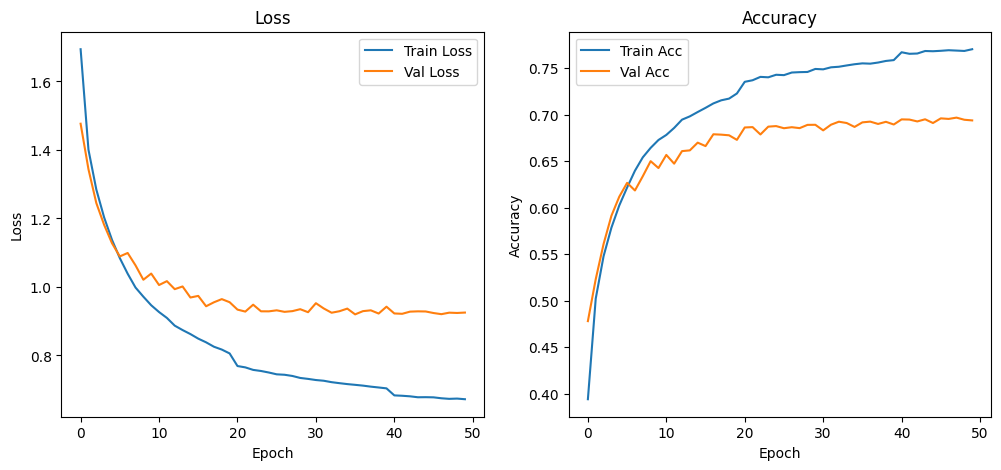

In [ ]:
params = init_cnn_params()
params, best_val_acc = train_cnn_functional_full(
    train_loader, val_loader,
    epochs=50, lr=1e-3, weight_decay=1e-4,
    scheduler_type="step", step_size=20, gamma=0.5,
    early_stop_patience=10, device=None,
    checkpoint_path="best_func_cnn.pth"
)

In [ ]:
results = {}

In [ ]:
results["Functional CNN"] = best_val_acc

In [ ]:
import json

results = {
    "CNN": best_val_acc
}

with open("results.json", "w") as f:
    json.dump(results, f)

In [ ]:
with open("results.json", "r") as f:
    results = json.load(f)
print(results)

{'CNN': 0.6968}


## RNN

In [12]:
# 1. Download the zip file from the URL
!wget https://download.pytorch.org/tutorial/data.zip

# 2. Unzip the file
# The '-o' flag overwrites existing files without asking, which is useful
!unzip -o data.zip

--2025-10-18 19:19:25--  https://download.pytorch.org/tutorial/data.zip
Resolving download.pytorch.org (download.pytorch.org)... 99.84.215.89, 99.84.215.76, 99.84.215.85, ...
Connecting to download.pytorch.org (download.pytorch.org)|99.84.215.89|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2882130 (2.7M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]   2.75M  --.-KB/s    in 0.05s   

2025-10-18 19:19:25 (51.6 MB/s) - ‘data.zip’ saved [2882130/2882130]

Archive:  data.zip
  inflating: data/eng-fra.txt        
   creating: data/names/
  inflating: data/names/Arabic.txt   
  inflating: data/names/Chinese.txt  
  inflating: data/names/Czech.txt    
  inflating: data/names/Dutch.txt    
  inflating: data/names/English.txt  
  inflating: data/names/French.txt   
  inflating: data/names/German.txt   
  inflating: data/names/Greek.txt    
  inflating: data/names/Irish.txt    
  inflating: data/names/Italian.txt  
  inflating

In [14]:
def rnn_step(x, h_prev, Wx, Wh, b):
    # x shape: (batch_size, input_size)
    # h_prev shape: (batch_size, hidden_size)
    h = torch.tanh(x @ Wx + h_prev @ Wh + b)
    return h

def rnn_forward(X, Wx, Wh, b, h0):
    # X shape: (batch_size, seq_len, input_size)
    # h0 shape: (batch_size, hidden_size)
    h = h0
    # Loop over time steps (characters in the name)
    for t in range(X.size(1)):
        h = rnn_step(X[:,t,:], h, Wx, Wh, b)
    return h  # Returns the *final* hidden state after the last character

In [15]:
all_letters = string.ascii_letters + " .,;'-"
n_letters = len(all_letters) + 1 # Plus one for EOS marker

def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

category_lines = {}
all_categories = []
for filename in glob.glob('data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)
print(f"Loaded {n_categories} categories (languages).")
print(f"Total letters in alphabet: {n_letters}")



def letterToIndex(letter):
    return all_letters.find(letter)

def lineToTensor(line):
    tensor = torch.zeros(len(line), n_letters)
    for li, letter in enumerate(line):
        tensor[li][letterToIndex(letter)] = 1 # One-hot encode the letter
    return tensor

def randomTrainingExample():
    category = random.choice(all_categories)
    line = random.choice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i]

Loaded 18 categories (languages).
Total letters in alphabet: 59


In [16]:
n_hidden = 128
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Initialize Parameters ---
Wx = nn.Parameter(torch.randn(n_letters, n_hidden, device=device) * 0.01)
Wh = nn.Parameter(torch.randn(n_hidden, n_hidden, device=device) * 0.01)
b = nn.Parameter(torch.zeros(n_hidden, device=device))
W_out = nn.Parameter(torch.randn(n_hidden, n_categories, device=device) * 0.01)
b_out = nn.Parameter(torch.zeros(n_categories, device=device))

params = [Wx, Wh, b, W_out, b_out]

print("Parameters initialized and moved to:", device)

Parameters initialized and moved to: cuda


In [17]:
def train_rnn_names(n_iters=100000, lr=0.005, print_every=5000):

    optimizer = torch.optim.SGD(params, lr=lr)
    train_losses = []
    current_loss = 0
    start = time.time()

    for iter in range(1, n_iters + 1):
        # 1. Get a random data sample
        category, line, category_tensor, line_tensor = randomTrainingExample()

        # Move data to the same device as params
        category_tensor = category_tensor.to(device)
        line_tensor = line_tensor.to(device)

        # 2. Add a batch dimension (batch_size=1)
        # line_tensor shape is (seq_len, input_size)
        # We need (1, seq_len, input_size) for rnn_forward
        X = line_tensor.unsqueeze(0)
        y = category_tensor # shape is (1,)

        # 3. Initialize hidden state
        # h0 shape: (batch_size, hidden_size)
        h0 = torch.zeros(1, n_hidden, device=device)

        # 4. Forward pass
        h = rnn_forward(X, Wx, Wh, b, h0)

        # 5. Get output logits
        logits = h @ W_out + b_out # shape (1, n_categories)

        # 6. Compute loss
        loss = F.cross_entropy(logits, y)

        # 7. Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        current_loss += loss.item()

        if iter % print_every == 0:
            avg_loss = current_loss / print_every
            train_losses.append(avg_loss)
            current_loss = 0

            guess = categoryFromOutput(logits)
            correct = '✓' if guess == category else f'✗ ({category})'
            print(f"Iter {iter} {iter/n_iters*100:.0f}% ({time.time()-start:.1f}s) "
                  f"Loss={avg_loss:.4f}  Name: {line} / Guess: {guess} {correct}")

    return train_losses

Starting RNN training on device: cuda
Iter 5000 5% (12.2s) Loss=2.8874  Name: Lapointe / Guess: Chinese ✗ (French)
Iter 10000 10% (23.8s) Loss=2.8596  Name: Oh  / Guess: Japanese ✗ (Korean)
Iter 15000 15% (35.6s) Loss=2.7072  Name: Stolarz / Guess: Italian ✗ (Polish)
Iter 20000 20% (47.3s) Loss=2.5127  Name: Gosselin / Guess: Russian ✗ (French)
Iter 25000 25% (59.0s) Loss=2.2429  Name: Egonidis / Guess: Greek ✓
Iter 30000 30% (70.8s) Loss=1.9738  Name: Gorecki / Guess: Polish ✓
Iter 35000 35% (82.5s) Loss=1.8453  Name: Donnell / Guess: German ✗ (Irish)
Iter 40000 40% (94.2s) Loss=1.7523  Name: Rudawski / Guess: Polish ✓
Iter 45000 45% (105.9s) Loss=1.7338  Name: Tong / Guess: Chinese ✗ (Vietnamese)
Iter 50000 50% (117.6s) Loss=1.6540  Name: Campbell / Guess: English ✗ (Scottish)
Iter 55000 55% (129.2s) Loss=1.6034  Name: Elinson / Guess: Scottish ✗ (Russian)
Iter 60000 60% (141.1s) Loss=1.5603  Name: Lieu / Guess: Chinese ✗ (Vietnamese)
Iter 65000 65% (152.6s) Loss=1.5160  Name: Wiltsh

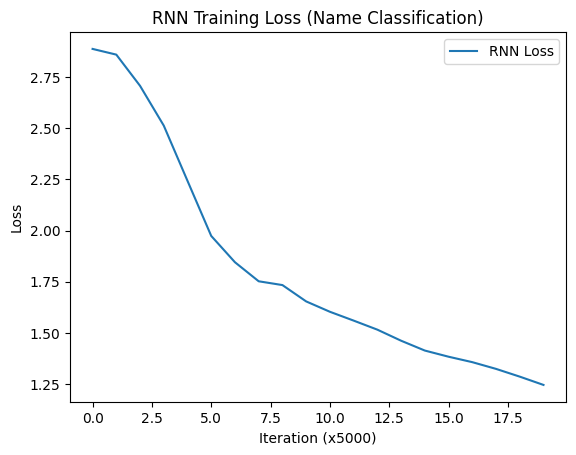

In [18]:
print("Starting RNN training on device:", device)
train_losses = train_rnn_names(n_iters=100000, lr=0.005, print_every=5000)

plt.plot(train_losses, label="RNN Loss")
plt.title("RNN Training Loss (Name Classification)")
plt.xlabel("Iteration (x5000)")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [2]:
!pip install --upgrade torch torchtext

## LSTM

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Hyperparameters ---
VOCAB_SIZE = 10000  # Keras dataset will be limited to this
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = 1      # 1 output neuron (for binary positive/negative)
N_LAYERS = 2      # We can use multiple layers now
LR = 1e-3
N_EPOCHS = 5
BATCH_SIZE = 64

(x_train, y_train), (x_test, y_test) = keras_datasets.imdb.load_data(
    num_words=VOCAB_SIZE,
    oov_char=2  # Out-of-vocabulary char
)

print(f"Loaded {len(x_train)} train examples and {len(x_test)} test examples.")
print("Example review (integers):", x_train[0][:15])
print("Example label:", y_train[0])

PAD_IDX = 0
START_TOKEN = 1
UNK_TOKEN = 2

Using device: cuda
Loaded 25000 train examples and 25000 test examples.
Example review (integers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4]
Example label: 1


In [20]:
word_index = keras_datasets.imdb.get_word_index()

word_to_idx = {word: (index + 3) for word, index in word_index.items()}
word_to_idx['<pad>'] = 0
word_to_idx['<start>'] = 1
word_to_idx['<unk>'] = 2

idx_to_word = {index: word for word, index in word_to_idx.items()}

In [21]:
class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = IMDBDataset(x_train, y_train)
test_dataset = IMDBDataset(x_test, y_test)

In [22]:
def collate_batch_keras(batch):
    label_list, text_list = [], []
    for (_text, _label) in batch:
        label_list.append(_label)

        processed_text = torch.tensor(_text, dtype=torch.int64)
        text_list.append(processed_text)

    padded_text_list = pad_sequence(text_list, batch_first=True, padding_value=PAD_IDX)

    labels = torch.tensor(label_list, dtype=torch.float32)
    return labels.to(device), padded_text_list.to(device)

In [23]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True, collate_fn=collate_batch_keras)
val_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, collate_fn=collate_batch_keras)

print(f"DataLoaders created.")

DataLoaders created.


In [28]:
class LSTM_Sentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, pad_idx):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=n_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text_batch):
        # text_batch shape: (batch_size, seq_len)

        # 1. Get sequence lengths *before* padding
        # We count how many tokens are NOT padding tokens
        seq_lengths = (text_batch != PAD_IDX).sum(dim=1)

        # We need to move lengths to CPU for pack_padded_sequence
        # and sort them in descending order (a requirement of pack_padded_sequence)
        seq_lengths, perm_idx = seq_lengths.cpu().sort(dim=0, descending=True)
        text_batch = text_batch[perm_idx]

        # 2. Pass through embedding layer
        # embedded shape: (batch_size, seq_len, embedding_dim)
        embedded = self.embedding(text_batch)

        # 3. Pack the sequence
        # This tells the LSTM to ignore padding
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded,
            seq_lengths,
            batch_first=True
        )

        # 4. Pass through LSTM
        # We don't need lstm_out, just the final hidden/cell
        packed_out, (hidden, cell) = self.lstm(packed_embedded)

        # 5. Get the final hidden state of the *last* layer
        # 'hidden' is now the *correct* state at the end of the
        # *non-padded* sequence.
        # hidden shape: (n_layers, batch_size, hidden_dim)
        final_hidden = hidden[-1]

        # 6. Un-sort the batch to its original order
        # We need to find the inverse permutation
        _, unperm_idx = perm_idx.sort(dim=0)
        final_hidden = final_hidden[unperm_idx]

        # 7. Pass through the final linear layer
        # prediction shape: (batch_size, 1)
        prediction = self.fc(final_hidden)

        # 8. Squeeze to remove the last dim, shape: (batch_size)
        return prediction.squeeze(1)

In [29]:
model = LSTM_Sentiment(
    VOCAB_SIZE,
    EMBEDDING_DIM,
    HIDDEN_DIM,
    OUTPUT_DIM,
    N_LAYERS,
    PAD_IDX
).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

criterion = nn.BCEWithLogitsLoss().to(device)

print(model)

LSTM_Sentiment(
  (embedding): Embedding(10000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [30]:
def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

def train_epoch(model, loader, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.train()

    for labels, text in loader:
        optimizer.zero_grad()
        predictions = model(text)
        loss = criterion(predictions, labels)
        acc = binary_accuracy(predictions, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(labels)
        epoch_acc += acc.item() * len(labels)

    return epoch_loss / len(loader.dataset), epoch_acc / len(loader.dataset)

def evaluate_epoch(model, loader, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.eval()

    with torch.no_grad():
        for labels, text in loader:
            predictions = model(text)
            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)
            epoch_loss += loss.item() * len(labels)
            epoch_acc += acc.item() * len(labels)

    return epoch_loss / len(loader.dataset), epoch_acc / len(loader.dataset)

In [31]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float('inf')
print("Starting training...")

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate_epoch(model, val_loader, criterion)

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_lstm_model.pth')

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins:.0f}m {epoch_secs:.0f}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {val_loss:.3f} |  Val. Acc: {val_acc*100:.2f}%')

print("Training finished.")

Starting training...
Epoch: 01 | Time: 0m 36s
	Train Loss: 0.632 | Train Acc: 62.57%
	 Val. Loss: 0.627 |  Val. Acc: 65.97%
Epoch: 02 | Time: 0m 36s
	Train Loss: 0.580 | Train Acc: 68.12%
	 Val. Loss: 0.659 |  Val. Acc: 60.20%
Epoch: 03 | Time: 0m 36s
	Train Loss: 0.455 | Train Acc: 78.47%
	 Val. Loss: 0.394 |  Val. Acc: 82.90%
Epoch: 04 | Time: 0m 36s
	Train Loss: 0.332 | Train Acc: 85.86%
	 Val. Loss: 0.365 |  Val. Acc: 84.40%
Epoch: 05 | Time: 0m 36s
	Train Loss: 0.260 | Train Acc: 89.44%
	 Val. Loss: 0.303 |  Val. Acc: 87.72%
Training finished.


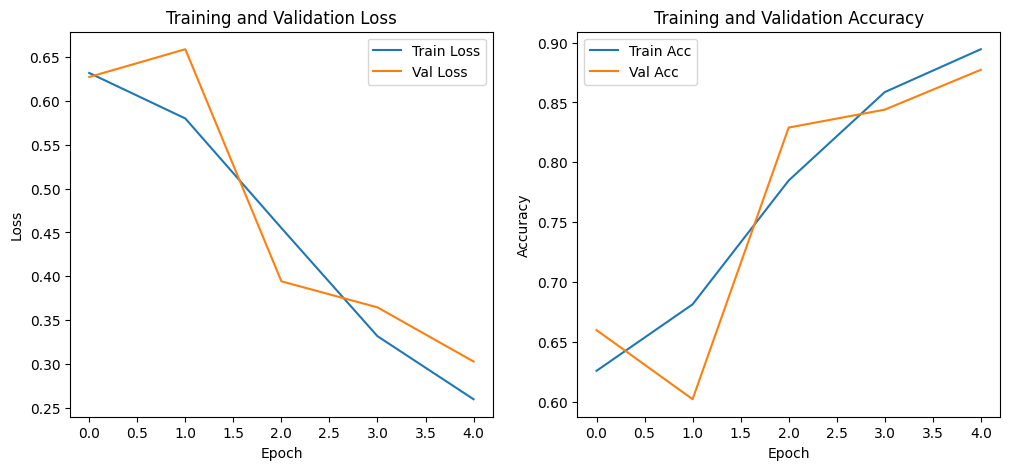

Review: "This movie was fantastic, I really loved it!"
Sentiment: Positive (Probability: 88.96%)
Review: "What a terrible film. I was so bored the entire time."
Sentiment: Negative (Probability: 4.19%)
Review: "It was an okay movie, not bad but not great either."
Sentiment: Negative (Probability: 33.75%)


In [32]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


def predict_sentiment_keras(model, sentence):
    model.eval()

    # 1. Process the sentence
    tokens = sentence.lower().split()

    # 2. Convert to indices using Keras vocab
    indexed_tokens = [START_TOKEN]
    for token in tokens:
        indexed_tokens.append(word_to_idx.get(token, UNK_TOKEN))

    tensor = torch.LongTensor(indexed_tokens).to(device)

    # 3. Add batch dimension and make prediction
    tensor = tensor.unsqueeze(0) # (1, seq_len)
    with torch.no_grad():
        prediction = model(tensor)

    # 4. Get probability and class
    prob = torch.sigmoid(prediction).item()
    sentiment = "Positive" if prob > 0.5 else "Negative"

    print(f'Review: "{sentence}"')
    print(f'Sentiment: {sentiment} (Probability: {prob*100:.2f}%)')

model.load_state_dict(torch.load('best_lstm_model.pth'))

predict_sentiment_keras(model, "This movie was fantastic, I really loved it!")
predict_sentiment_keras(model, "What a terrible film. I was so bored the entire time.")
predict_sentiment_keras(model, "It was an okay movie, not bad but not great either.")

## Transformers

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Hyperparameters ---
VOCAB_SIZE = 10000  # Keras dataset will be limited to this
EMBEDDING_DIM = 128 # Transformers often use smaller embedding dims with more heads
HIDDEN_DIM = 128    # Not really 'hidden' but the model's main dimension
OUTPUT_DIM = 1
N_LAYERS = 2      # Number of Transformer Encoder layers
N_HEADS = 4       # Number of "attention heads"
DROPOUT = 0.1
LR = 1e-4         # Transformers often prefer smaller learning rates
N_EPOCHS = 5
BATCH_SIZE = 64

(x_train, y_train), (x_test, y_test) = keras_datasets.imdb.load_data(
    num_words=VOCAB_SIZE,
    oov_char=2
)

print(f"Loaded {len(x_train)} train examples and {len(x_test)} test examples.")

PAD_IDX = 0
START_TOKEN = 1
UNK_TOKEN = 2

Using device: cuda
Loaded 25000 train examples and 25000 test examples.


In [35]:
word_index = keras_datasets.imdb.get_word_index()

word_to_idx = {word: (index + 3) for word, index in word_index.items()}
word_to_idx['<pad>'] = 0
word_to_idx['<start>'] = 1
word_to_idx['<unk>'] = 2

idx_to_word = {index: word for word, index in word_to_idx.items()}

In [36]:
class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = IMDBDataset(x_train, y_train)
test_dataset = IMDBDataset(x_test, y_test)

In [37]:
def collate_batch_keras(batch):
    label_list, text_list = [], []
    for (_text, _label) in batch:
        label_list.append(_label)
        processed_text = torch.tensor(_text, dtype=torch.int64)
        text_list.append(processed_text)

    padded_text_list = pad_sequence(text_list, batch_first=True, padding_value=PAD_IDX)

    labels = torch.tensor(label_list, dtype=torch.float32)
    return labels.to(device), padded_text_list.to(device)

In [38]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True, collate_fn=collate_batch_keras)
val_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, collate_fn=collate_batch_keras)

print(f"DataLoaders created.")

DataLoaders created.


In [39]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe.transpose(0, 1)[:, :x.size(1), :]
        return self.dropout(x)

class Transformer_Sentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim, n_heads, n_layers, hidden_dim, dropout, pad_idx):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_encoder = PositionalEncoding(embed_dim, dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.fc = nn.Linear(embed_dim, OUTPUT_DIM)
        self.pad_idx = pad_idx

    def forward(self, text_batch):
        mask = (text_batch == self.pad_idx)

        embedded = self.embedding(text_batch) * math.sqrt(EMBEDDING_DIM)
        pos_embedded = self.pos_encoder(embedded)

        transformer_out = self.transformer_encoder(
            pos_embedded,
            src_key_padding_mask=mask
        )

        transformer_out[mask] = 0

        pooled_out = transformer_out.sum(dim=1)
        non_pad_count = (text_batch != self.pad_idx).sum(dim=1).unsqueeze(1)
        pooled_out = pooled_out / non_pad_count # (batch_size, embed_dim)

        prediction = self.fc(pooled_out)

        return prediction.squeeze(1)

In [40]:
model = Transformer_Sentiment(
    VOCAB_SIZE,
    EMBEDDING_DIM,
    N_HEADS,
    N_LAYERS,
    HIDDEN_DIM,
    DROPOUT,
    PAD_IDX
).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

criterion = nn.BCEWithLogitsLoss().to(device)

print(model)

Transformer_Sentiment(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [41]:
def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

def train_epoch(model, loader, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.train()

    for labels, text in loader:
        optimizer.zero_grad()
        predictions = model(text)
        loss = criterion(predictions, labels)
        acc = binary_accuracy(predictions, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(labels)
        epoch_acc += acc.item() * len(labels)

    return epoch_loss / len(loader.dataset), epoch_acc / len(loader.dataset)

def evaluate_epoch(model, loader, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.eval()

    with torch.no_grad():
        for labels, text in loader:
            predictions = model(text)
            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)
            epoch_loss += loss.item() * len(labels)
            epoch_acc += acc.item() * len(labels)

    return epoch_loss / len(loader.dataset), epoch_acc / len(loader.dataset)

In [42]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float('inf')
print("Starting training...")

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate_epoch(model, val_loader, criterion)

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_transformer_model.pth')

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins:.0f}m {epoch_secs:.0f}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {val_loss:.3f} |  Val. Acc: {val_acc*100:.2f}%')

print("Training finished.")

Starting training...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch: 01 | Time: 1m 23s
	Train Loss: 0.599 | Train Acc: 67.26%
	 Val. Loss: 0.517 |  Val. Acc: 74.50%
Epoch: 02 | Time: 1m 25s
	Train Loss: 0.488 | Train Acc: 76.32%
	 Val. Loss: 0.459 |  Val. Acc: 78.29%
Epoch: 03 | Time: 1m 25s
	Train Loss: 0.440 | Train Acc: 79.51%
	 Val. Loss: 0.422 |  Val. Acc: 80.35%
Epoch: 04 | Time: 1m 25s
	Train Loss: 0.412 | Train Acc: 81.10%
	 Val. Loss: 0.423 |  Val. Acc: 80.75%
Epoch: 05 | Time: 1m 25s
	Train Loss: 0.395 | Train Acc: 82.01%
	 Val. Loss: 0.400 |  Val. Acc: 81.94%
Training finished.


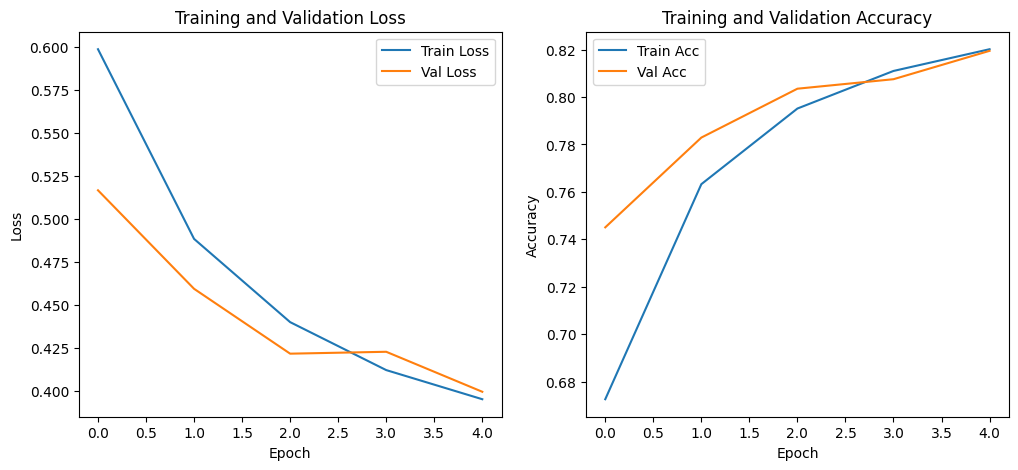

Review: "This movie was fantastic, I really loved it!"
Sentiment: Positive (Probability: 80.97%)
Review: "What a terrible film. I was so bored the entire time."
Sentiment: Negative (Probability: 0.48%)
Review: "It was an okay movie, not bad but not great either."
Sentiment: Negative (Probability: 1.83%)


In [43]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# --- Prediction Function (identical to LSTM's) ---
def predict_sentiment_keras(model, sentence):
    model.eval()

    # 1. Process the sentence
    tokens = sentence.lower().split()

    # 2. Convert to indices using Keras vocab
    indexed_tokens = [START_TOKEN]
    for token in tokens:
        indexed_tokens.append(word_to_idx.get(token, UNK_TOKEN))

    tensor = torch.LongTensor(indexed_tokens).to(device)

    # 3. Add batch dimension and make prediction
    tensor = tensor.unsqueeze(0) # (1, seq_len)
    with torch.no_grad():
        prediction = model(tensor)

    # 4. Get probability and class
    prob = torch.sigmoid(prediction).item()
    sentiment = "Positive" if prob > 0.5 else "Negative"

    print(f'Review: "{sentence}"')
    print(f'Sentiment: {sentiment} (Probability: {prob*100:.2f}%)')

model.load_state_dict(torch.load('best_transformer_model.pth'))

predict_sentiment_keras(model, "This movie was fantastic, I really loved it!")
predict_sentiment_keras(model, "What a terrible film. I was so bored the entire time.")
predict_sentiment_keras(model, "It was an okay movie, not bad but not great either.")

## Final Table

In [45]:
data = {
    "Model": ["CNN", "RNN", "LSTM", "Transformer"],
    "Task": ["Image Classification",
             "Sequence Classification",
             "Sentiment Analysis",
             "Sentiment Analysis"],
    "Dataset": ["CIFAR-10",
                "\"Names by Origin\"",
                "IMDB Reviews",
                "IMDB Reviews"],
    "Data Type & Challenge": [
        "2D Spatial Data: Finding patterns (edges, shapes) in a grid.",
        "Short Sequences: Reading characters one-by-one to find a pattern.",
        "Long Sequences: Understanding context over hundreds of words; avoiding the 'forgetting' problem.",
        "Long Sequences: Using parallel 'attention' to see all words at once."
    ],
    "Best Result (Metric)": ["69.68% (Val Acc)",
                             "1.246 (Final Train Loss)",
                             "87.72% (Val Acc)",
                             "81.94% (Val Acc)"]
}

df = pd.DataFrame(data)

print("=====================================================")
print("           PROJECT SUMMARY: MODEL COMPARISON         ")
print("=====================================================")
display(df)

           PROJECT SUMMARY: MODEL COMPARISON         


,Model,Task,Dataset,Data Type & Challenge,Best Result (Metric)
0,CNN,Image Classification,CIFAR-10,"2D Spatial Data: Finding patterns (edges, shap...",69.68% (Val Acc)
1,RNN,Sequence Classification,"""Names by Origin""",Short Sequences: Reading characters one-by-one...,1.246 (Final Train Loss)
2,LSTM,Sentiment Analysis,IMDB Reviews,Long Sequences: Understanding context over hun...,87.72% (Val Acc)
3,Transformer,Sentiment Analysis,IMDB Reviews,Long Sequences: Using parallel 'attention' to ...,81.94% (Val Acc)
